## Paso 1: Importar bibliotecas

In [31]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

## Paso 2: Cargar el dataset Fashion MNIST

In [32]:
# Load the MNIST dataset using keras directly
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Training images shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test images shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


## Paso 3: Visualizar ejemplos por etiqueta

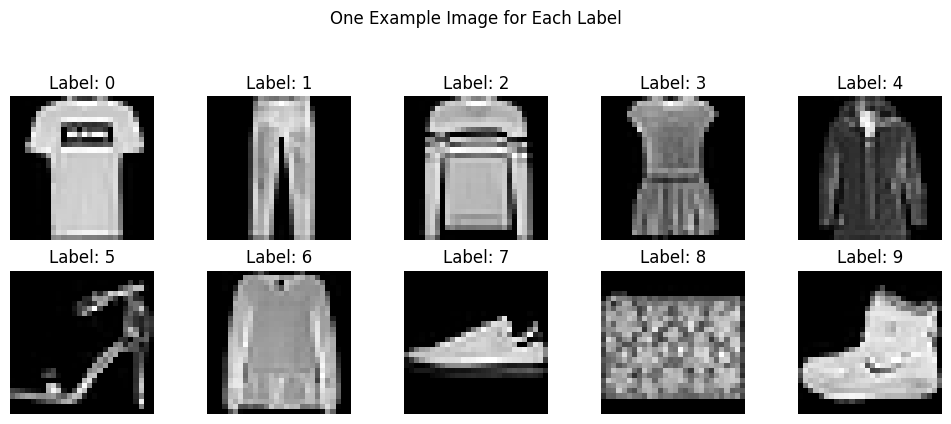

In [33]:
# Display one image from each label (0 to 9)
plt.figure(figsize=(10, 4))
unique_labels = np.unique(y_train)
for idx, label in enumerate(unique_labels):
    plt.subplot(2, 5, idx + 1)
    # Find the first occurrence of the label in y_train
    image = x_train[y_train == label][0]
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.suptitle("One Example Image for Each Label", y=1.05)
plt.tight_layout()
plt.show()

## Paso 4: Construir el modelo

In [34]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(784,)))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

## Paso 5: Compilar el modelo

In [35]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## Paso 6: Entrenar el modelo

In [36]:
model.fit(x_train.reshape(60000, 784), y_train, epochs=5, validation_data=(x_test.reshape(10000, 784), y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7416 - loss: 2.5091 - val_accuracy: 0.7596 - val_loss: 0.8113
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7842 - loss: 0.6756 - val_accuracy: 0.7944 - val_loss: 0.6838
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8026 - loss: 0.5984 - val_accuracy: 0.8023 - val_loss: 0.6641
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8171 - loss: 0.5497 - val_accuracy: 0.8033 - val_loss: 0.5559
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8304 - loss: 0.4996 - val_accuracy: 0.8332 - val_loss: 0.4970


## Paso 7: Evaluar el modelo con la matriz de confusión

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


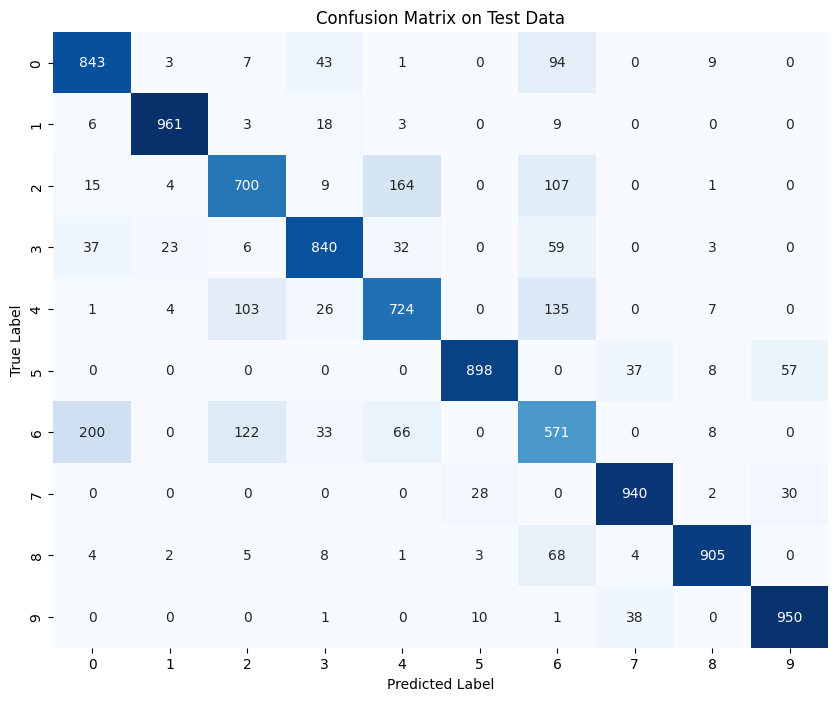

In [37]:
# Make predictions on the test set
y_pred_probabilities = model.predict(x_test.reshape(10000, 784))
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Data')
plt.show()

## Paso 8: Crear y visualizar una prenda de ejemplo

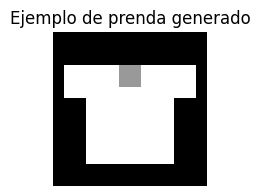

In [38]:
# Construimos una "camiseta" mucho más grande y simple para el ejemplo
camiseta = np.zeros((28, 28), dtype='uint8')

# Gran cuerpo central de la camiseta
camiseta[6:24, 6:22] = 200  # Más ancho y bajo

# Mangas gruesas y largas, totalmente extendidas
camiseta[6:12, 2:6] = 200   # Manga izquierda, más grande
camiseta[6:12, 22:26] = 200 # Manga derecha, más grande

# Cuello simple, más notorio
camiseta[6:10, 12:16] = 120

plt.figure(figsize=(2, 2))
plt.imshow(camiseta, cmap='gray')
plt.title('Ejemplo de prenda generado')
plt.axis('off')
plt.show()

## Paso 9: Predecir la etiqueta de la prenda

In [39]:
probabilidades = model.predict(camiseta.reshape(1, 784))
etiqueta_predicha = np.argmax(probabilidades)
print(f'La etiqueta predicha es: {etiqueta_predicha} con probabilidad: {probabilidades[0][etiqueta_predicha]:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
La etiqueta predicha es: 0 con probabilidad: 0.9094


## Paso 10: Comparación con modelo tradicional de Machine Learning

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

clf_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
clf_rf.fit(x_train.reshape(60000, 784), y_train)

y_pred_rf = clf_rf.predict(x_test.reshape(10000, 784))
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_nn = model.evaluate(x_test.reshape(10000, 784), y_test, verbose=0)[1]

print(f"Accuracy - Red Neuronal Densa : {acc_nn:.4f}")
print(f"Accuracy - Random Forest      : {acc_rf:.4f}")

Accuracy - Red Neuronal Densa : 0.8332
Accuracy - Random Forest      : 0.8760
